# Differentiable programming: detector optimisation

(C) Pietro Vischia, 2025  

Prepared with assistance from CODEX with GPT-5.4.

In this notebook we build a small differentiable detector-design problem from end to end.

The toy setup is deliberately simple, but it contains the main ingredients that make differentiable programming interesting for instrumentation:

- cosmic muons are generated at fixed momentum from a Gaisser/Geisser-style angular spectrum,
- they cross two upper muon panels,
- they scatter inside a passive volume made of 6 layers,
- they exit through two lower muon panels,
- we reconstruct a point of closest approach (POCA),
- we infer the radiation length $X_0$ from the batch-average scattering angle,
- and we optimise the panel positions and voxel efficiencies while penalising detector cost.

This is not a full detector simulation. The goal is to show how a physics-inspired pipeline can remain differentiable enough that gradient-based optimisation becomes useful.


## Imports and constants

We will use PyTorch for automatic differentiation, NumPy for a few convenience operations, and Matplotlib for visualisation.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(7)
DEVICE = torch.device("cpu")

P_MUON_GEV = 3.0
MUON_MASS_GEV = 0.105658
BETA = P_MUON_GEV / math.sqrt(P_MUON_GEV**2 + MUON_MASS_GEV**2)

PASSIVE_THICKNESS_M = 1.0
PASSIVE_SIZE_M = 1.0
N_PASSIVE_LAYERS = 6
N_PASSIVE_VOXELS_XY = 10

BERYLLIUM_X0_M = 0.353
URANIUM_X0_M = 0.0032

PANEL_SIZE_M = 0.5
PANEL_SIZE_MIN_M = 0.3
PANEL_SIZE_MAX_M = 2.4
N_VOXELS = 10
BATCH_SIZE = 512
EDGE_SHARPNESS = 18.0
BASE_HIT_SIGMA_M = 0.01

HIGHLAND = 0.0136 / (P_MUON_GEV * BETA)
LAYER_THICKNESS_M = PASSIVE_THICKNESS_M / N_PASSIVE_LAYERS
VOXEL_SIZE_XY_M = PASSIVE_SIZE_M / N_PASSIVE_VOXELS_XY

true_x0_map = torch.full((N_PASSIVE_LAYERS, N_PASSIVE_VOXELS_XY, N_PASSIVE_VOXELS_XY), BERYLLIUM_X0_M)
true_x0_map[2:4, 3:6, 3:6] = URANIUM_X0_M
true_uranium_map = torch.zeros((N_PASSIVE_LAYERS, N_PASSIVE_VOXELS_XY, N_PASSIVE_VOXELS_XY))
true_uranium_map[2:4, 3:6, 3:6] = 1.0
TRUE_URANIUM_FRACTION = float(true_uranium_map.mean())

print(f"Muon momentum: {P_MUON_GEV:.1f} GeV")
print(f"Passive thickness: {PASSIVE_THICKNESS_M:.2f} m split into {N_PASSIVE_LAYERS} layers")
print(f"Passive material: beryllium with X0 = {BERYLLIUM_X0_M:.3f} m")
print(f"Embedded block: 3x3x2 uranium block with X0 = {URANIUM_X0_M:.4f} m")
print("Training target: per-voxel uranium probability (1 = uranium, 0 = beryllium)")
print(f"True uranium voxel fraction: {TRUE_URANIUM_FRACTION:.4f}")


Muon momentum: 3.0 GeV
Passive thickness: 1.00 m split into 6 layers
Passive material: beryllium with X0 = 0.353 m
Embedded block: 3x3x2 uranium block with X0 = 0.0032 m
Training target: per-voxel uranium probability (1 = uranium, 0 = beryllium)
True uranium voxel fraction: 0.0300


## Muon generation with a fixed-momentum Gaisser spectrum

For a fixed momentum, the Gaisser parameterisation only needs to tell us how the flux changes with zenith angle. We ignore overall normalisation and use the angular dependence to sample incoming tracks.

A commonly used approximation is

$$
I(\theta) \propto p^{-2.7}\left(\frac{1}{1 + 1.1p\cos\theta / 115} + \frac{0.054}{1 + 1.1p\cos\theta / 850}\right)\cos^2\theta.
$$

The extra $\cos^2\theta$ factor makes the near-vertical directions more likely, as expected for cosmic muons at the surface.


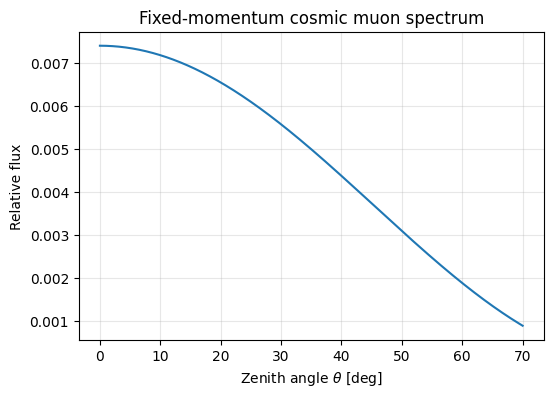

In [2]:
def gaisser_flux_fixed_momentum(theta, momentum_gev=P_MUON_GEV):
    cos_theta = torch.cos(theta).clamp_min(0.05)
    term_pi = 1.0 / (1.0 + 1.1 * momentum_gev * cos_theta / 115.0)
    term_k = 0.054 / (1.0 + 1.1 * momentum_gev * cos_theta / 850.0)
    return 0.14 * momentum_gev**(-2.7) * (term_pi + term_k) * cos_theta**2


theta_grid = torch.linspace(0.0, math.radians(70.0), 1000)
flux = gaisser_flux_fixed_momentum(theta_grid)

plt.figure(figsize=(6, 4))
plt.plot(theta_grid.numpy() * 180.0 / math.pi, flux.numpy())
plt.xlabel(r"Zenith angle $\theta$ [deg]")
plt.ylabel("Relative flux")
plt.title("Fixed-momentum cosmic muon spectrum")
plt.grid(alpha=0.3)
plt.show()


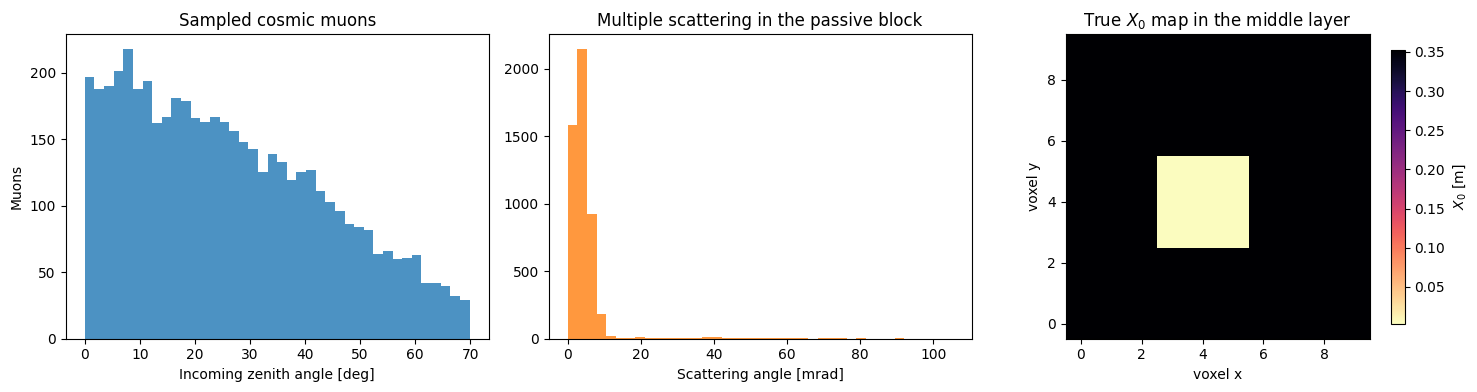

In [3]:
def xy_to_voxel_index(xy):
    shifted = (xy + 0.5 * PASSIVE_SIZE_M) / PASSIVE_SIZE_M
    return torch.clamp((shifted * N_PASSIVE_VOXELS_XY).long(), 0, N_PASSIVE_VOXELS_XY - 1)


def sample_muons(n_muons, device=DEVICE):
    theta_grid = torch.linspace(0.0, math.radians(70.0), 4096, device=device)
    pdf = gaisser_flux_fixed_momentum(theta_grid)
    pdf = pdf / torch.trapz(pdf, theta_grid)

    cdf = torch.cumsum((pdf[:-1] + pdf[1:]) * 0.5 * (theta_grid[1] - theta_grid[0]), dim=0)
    cdf = torch.cat([torch.zeros(1, device=device), cdf])
    cdf = cdf / cdf[-1]

    u = torch.rand(n_muons, device=device)
    idx = torch.searchsorted(cdf, u, right=True).clamp(1, len(theta_grid) - 1)
    c0, c1 = cdf[idx - 1], cdf[idx]
    t0, t1 = theta_grid[idx - 1], theta_grid[idx]
    frac = (u - c0) / (c1 - c0 + 1e-12)
    theta = t0 + frac * (t1 - t0)

    phi = 2.0 * math.pi * torch.rand(n_muons, device=device)
    slopes_in = torch.stack([
        torch.tan(theta) * torch.cos(phi),
        torch.tan(theta) * torch.sin(phi),
    ], dim=-1)

    entry_xy = (torch.rand(n_muons, 2, device=device) - 0.5) * 0.9

    scatter_z = PASSIVE_THICKNESS_M * torch.rand(n_muons, device=device)
    scatter_xy = entry_xy + slopes_in * scatter_z[:, None]

    layer_index = torch.clamp((scatter_z / LAYER_THICKNESS_M).long(), 0, N_PASSIVE_LAYERS - 1)
    xy_index = xy_to_voxel_index(scatter_xy)
    local_x0 = true_x0_map[layer_index, xy_index[:, 1], xy_index[:, 0]].to(device)
    scatter_sigma = HIGHLAND * torch.sqrt(LAYER_THICKNESS_M / local_x0.clamp_min(1e-6))
    scatter_kick = scatter_sigma[:, None] * torch.randn(n_muons, 2, device=device)
    slopes_out = slopes_in + scatter_kick

    return {
        "entry_xy": entry_xy,
        "slopes_in": slopes_in,
        "scatter_z": scatter_z,
        "scatter_xy": scatter_xy,
        "slopes_out": slopes_out,
        "scatter_kick": scatter_kick,
        "layer_index": layer_index,
        "xy_index": xy_index,
        "local_x0": local_x0,
    }


muons = sample_muons(5000)
theta_in = torch.linalg.norm(muons["slopes_in"], dim=-1).atan()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(theta_in.numpy() * 180.0 / math.pi, bins=40, color="tab:blue", alpha=0.8)
axes[0].set_xlabel(r"Incoming zenith angle [deg]")
axes[0].set_ylabel("Muons")
axes[0].set_title("Sampled cosmic muons")

axes[1].hist(torch.linalg.norm(muons["scatter_kick"], dim=-1).numpy() * 1e3, bins=40, color="tab:orange", alpha=0.8)
axes[1].set_xlabel("Scattering angle [mrad]")
axes[1].set_title("Multiple scattering in the passive block")

image = axes[2].imshow(true_x0_map[N_PASSIVE_LAYERS // 2].numpy(), origin="lower", cmap="magma_r")
axes[2].set_title(r"True $X_0$ map in the middle layer")
axes[2].set_xlabel("voxel x")
axes[2].set_ylabel("voxel y")
fig.colorbar(image, ax=axes[2], shrink=0.9, label=r"$X_0$ [m]")

plt.tight_layout()
plt.show()


## A differentiable panel detector

Each detector panel is a $10 \times 10$ efficiency map. A muon crossing the panel does not get accepted with a hard yes/no decision. Instead, we assign a **soft detection probability**:

- a sigmoid edge keeps the panel boundary differentiable,
- bilinear interpolation reads the local voxel efficiency,
- the product of the four panel probabilities becomes the event weight.

This is the key differentiable-programming trick in the notebook: instead of discrete detector logic, we work with smooth approximations that still preserve the detector intuition.


In [4]:
def panel_response(muons, z, xy_offset, panel_size, efficiency_logits, base_hit_sigma=BASE_HIT_SIGMA_M):
    delta_z = z - muons["scatter_z"]
    slopes = torch.where(delta_z[:, None] <= 0.0, muons["slopes_in"], muons["slopes_out"])
    true_hit_xy = muons["scatter_xy"] + slopes * delta_z[:, None]

    relative_xy = true_hit_xy - xy_offset
    half_size = panel_size / 2.0

    edge_x = torch.sigmoid(EDGE_SHARPNESS * (half_size - relative_xy[:, 0].abs()))
    edge_y = torch.sigmoid(EDGE_SHARPNESS * (half_size - relative_xy[:, 1].abs()))
    inside_probability = edge_x * edge_y

    grid = (relative_xy / half_size).view(1, -1, 1, 2)
    efficiency_map = torch.sigmoid(efficiency_logits).unsqueeze(0).unsqueeze(0)
    local_efficiency = F.grid_sample(
        efficiency_map,
        grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=True,
    ).view(-1)

    detection_probability = inside_probability * local_efficiency

    # Lower efficiency means less charge/light and therefore worse spatial precision.
    position_sigma = base_hit_sigma / torch.sqrt(local_efficiency.clamp_min(1e-3))
    measured_hit_xy = true_hit_xy + position_sigma[:, None] * torch.randn_like(true_hit_xy)
    return detection_probability, measured_hit_xy, true_hit_xy, position_sigma


def infer_x0_voxel_map(theta2, event_weight, z_index, xy_index):
    x0_map_hat = torch.full((N_PASSIVE_LAYERS, N_PASSIVE_VOXELS_XY, N_PASSIVE_VOXELS_XY), float("nan"), device=theta2.device)
    weight_map = torch.zeros((N_PASSIVE_LAYERS, N_PASSIVE_VOXELS_XY, N_PASSIVE_VOXELS_XY), device=theta2.device)

    for z in range(N_PASSIVE_LAYERS):
        for y in range(N_PASSIVE_VOXELS_XY):
            for x in range(N_PASSIVE_VOXELS_XY):
                mask = ((z_index == z) & (xy_index[:, 0] == x) & (xy_index[:, 1] == y)).float()
                weighted_mask = event_weight * mask
                total_weight = weighted_mask.sum()
                if total_weight.item() > 0.0:
                    theta2_mean = (weighted_mask * theta2).sum() / total_weight
                    x0_map_hat[z, y, x] = LAYER_THICKNESS_M * HIGHLAND**2 / theta2_mean.clamp_min(1e-8)
                    weight_map[z, y, x] = total_weight

    return x0_map_hat, weight_map


def x0_to_uranium_probability(x0_map_hat, weight_map):
    log_x0 = torch.log(x0_map_hat.clamp_min(1e-6))
    log_beryllium = math.log(BERYLLIUM_X0_M)
    log_uranium = math.log(URANIUM_X0_M)
    uranium_score = (log_beryllium - log_x0) / (log_beryllium - log_uranium)
    uranium_score = uranium_score.clamp(0.0, 1.0)
    raw_probability = torch.sigmoid((uranium_score - 0.82) / 0.08)
    prior_probability = torch.full_like(raw_probability, TRUE_URANIUM_FRACTION)
    coverage_confidence = 1.0 - torch.exp(-weight_map / 6.0)
    blended_probability = prior_probability + coverage_confidence * (raw_probability - prior_probability)
    return torch.where(torch.isfinite(x0_map_hat), blended_probability, prior_probability)


class DifferentiableMuonTelescope(nn.Module):
    def __init__(self):
        super().__init__()

        self.top_z_logits = nn.Parameter(torch.tensor([-0.3, 0.8]))
        self.bottom_z_logits = nn.Parameter(torch.tensor([-0.2, 0.7]))

        self.top_offsets = nn.Parameter(torch.tensor([[0.25, -0.15], [-0.20, 0.10]], dtype=torch.float32))
        self.bottom_offsets = nn.Parameter(torch.tensor([[0.15, 0.16], [-0.22, -0.18]], dtype=torch.float32))
        initial_size_fraction = (PANEL_SIZE_M - PANEL_SIZE_MIN_M) / (PANEL_SIZE_MAX_M - PANEL_SIZE_MIN_M)
        initial_size_fraction = torch.tensor(initial_size_fraction, dtype=torch.float32).clamp(1e-4, 1.0 - 1e-4)
        initial_size_logit = torch.log(initial_size_fraction / (1.0 - initial_size_fraction))
        self.panel_size_logits = nn.Parameter(torch.full((4,), initial_size_logit.item()))

        initial_efficiency = torch.full((4, N_VOXELS, N_VOXELS), -0.15)
        self.efficiency_logits = nn.Parameter(initial_efficiency)

    def panel_zs(self):
        top_near = 1.10 + 0.45 * torch.sigmoid(self.top_z_logits[0])
        top_far = top_near + 0.20 + 0.60 * torch.sigmoid(self.top_z_logits[1])

        bottom_near = -(0.10 + 0.45 * torch.sigmoid(self.bottom_z_logits[0]))
        bottom_far = bottom_near - (0.20 + 0.60 * torch.sigmoid(self.bottom_z_logits[1]))

        return torch.stack([top_near, top_far, bottom_near, bottom_far])

    def panel_sizes(self):
        return PANEL_SIZE_MIN_M + (PANEL_SIZE_MAX_M - PANEL_SIZE_MIN_M) * torch.sigmoid(self.panel_size_logits)

    def forward(self, muons):
        zs = self.panel_zs()
        offsets = torch.cat([self.top_offsets, self.bottom_offsets], dim=0)
        panel_sizes = self.panel_sizes()

        detection_probabilities = []
        measured_hits = []
        true_hits = []
        position_sigmas = []

        for i in range(4):
            response = panel_response(muons, zs[i], offsets[i], panel_sizes[i], self.efficiency_logits[i])
            detection_probabilities.append(response[0])
            measured_hits.append(response[1])
            true_hits.append(response[2])
            position_sigmas.append(response[3])

        event_weight = torch.stack(detection_probabilities, dim=0).prod(dim=0)
        weight_norm = event_weight.sum().clamp_min(1e-8)

        top_hits = torch.stack(measured_hits[:2], dim=1)
        bottom_hits = torch.stack(measured_hits[2:], dim=1)

        top_dz = zs[1] - zs[0]
        bottom_dz = zs[3] - zs[2]

        top_slopes = (top_hits[:, 1] - top_hits[:, 0]) / (top_dz + 1e-6)
        bottom_slopes = (bottom_hits[:, 1] - bottom_hits[:, 0]) / (bottom_dz + 1e-6)

        top_mid_z = 0.5 * (zs[0] + zs[1])
        bottom_mid_z = 0.5 * (zs[2] + zs[3])
        top_mid_xy = top_hits.mean(dim=1)
        bottom_mid_xy = bottom_hits.mean(dim=1)

        top_anchor = top_mid_xy - top_slopes * top_mid_z
        bottom_anchor = bottom_mid_xy - bottom_slopes * bottom_mid_z
        delta_anchor = bottom_anchor - top_anchor
        delta_slopes = bottom_slopes - top_slopes

        poca_z_raw = -(delta_anchor * delta_slopes).sum(dim=-1) / delta_slopes.square().sum(dim=-1).clamp_min(1e-8)
        poca_in_volume = (poca_z_raw >= 0.0) & (poca_z_raw <= PASSIVE_THICKNESS_M)
        poca_z = poca_z_raw.clamp(0.0, PASSIVE_THICKNESS_M)

        top_at_poca = top_anchor + top_slopes * poca_z[:, None]
        bottom_at_poca = bottom_anchor + bottom_slopes * poca_z[:, None]
        poca_xy = 0.5 * (top_at_poca + bottom_at_poca)

        scatter_vector = delta_slopes
        theta2 = scatter_vector.square().sum(dim=-1)

        weighted_theta2 = (event_weight * theta2).sum() / weight_norm
        x0_hat = PASSIVE_THICKNESS_M * HIGHLAND**2 / weighted_theta2.clamp_min(1e-8)

        true_layer_index = muons["layer_index"]
        reconstructed_layer_index = torch.clamp((poca_z / LAYER_THICKNESS_M).long(), 0, N_PASSIVE_LAYERS - 1)
        reconstructed_xy_index = xy_to_voxel_index(poca_xy)
        reconstructed_event_weight = event_weight * poca_in_volume.float()

        true_x0_map_hat, true_weight_map = infer_x0_voxel_map(theta2, event_weight, true_layer_index, muons["xy_index"])
        reconstructed_x0_map_hat, reconstructed_weight_map = infer_x0_voxel_map(theta2, reconstructed_event_weight, reconstructed_layer_index, reconstructed_xy_index)
        reconstructed_uranium_probability = x0_to_uranium_probability(reconstructed_x0_map_hat, reconstructed_weight_map)

        poca_spread = (event_weight * poca_xy.square().sum(dim=-1)).sum() / weight_norm
        average_sigma2 = (event_weight * torch.stack(position_sigmas, dim=0).mean(dim=0).square()).sum() / weight_norm
        acceptance = event_weight.mean()
        mean_efficiency = torch.sigmoid(self.efficiency_logits).mean()
        total_panel_area = panel_sizes.square().sum()
        normalised_area_cost = total_panel_area / (4.0 * PANEL_SIZE_MAX_M**2)

        return {
            "x0_hat": x0_hat,
            "theta2_hat": weighted_theta2,
            "poca_xy": poca_xy,
            "poca_z": poca_z,
            "poca_spread": poca_spread,
            "resolution_penalty": average_sigma2,
            "acceptance": acceptance,
            "cost": normalised_area_cost,
            "total_panel_area": total_panel_area,
            "mean_efficiency": mean_efficiency,
            "event_weight": event_weight,
            "theta2": theta2,
            "true_layer_index": true_layer_index,
            "reconstructed_layer_index": reconstructed_layer_index,
            "reconstructed_xy_index": reconstructed_xy_index,
            "poca_in_volume": poca_in_volume,
            "true_x0_map_hat": true_x0_map_hat,
            "reconstructed_x0_map_hat": reconstructed_x0_map_hat,
            "reconstructed_uranium_probability": reconstructed_uranium_probability,
            "true_weight_map": true_weight_map,
            "reconstructed_weight_map": reconstructed_weight_map,
            "zs": zs,
            "offsets": offsets,
            "panel_sizes": panel_sizes,
            "true_hits": true_hits,
        }


## Initial detector behaviour

Before training, let us inspect the detector geometry and the corresponding estimate of $X_0$.


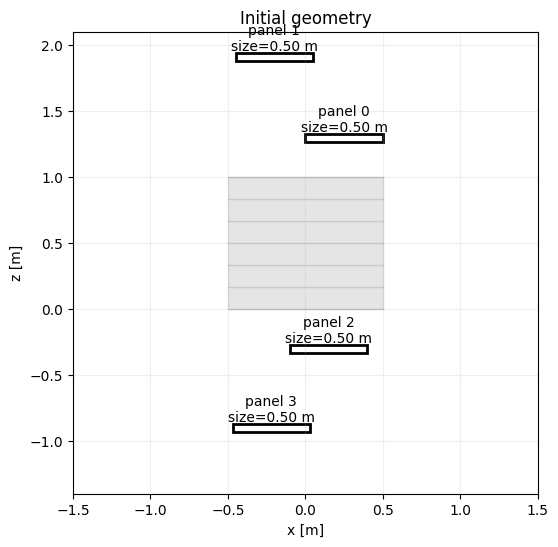

Initial X0 estimate: 0.010 m
Initial acceptance proxy: 0.0000
Initial total panel area: 1.000 m^2
Initial normalised area cost: 0.0434
Initial mean panel efficiency: 0.4626


In [5]:
def plot_geometry(model, title):
    zs = model.panel_zs().detach().numpy()
    offsets = torch.cat([model.top_offsets, model.bottom_offsets], dim=0).detach().numpy()
    panel_sizes = model.panel_sizes().detach().numpy()

    fig, ax = plt.subplots(figsize=(6, 6))

    for i, (z, offset, size) in enumerate(zip(zs, offsets, panel_sizes)):
        half = size / 2.0
        rect = plt.Rectangle((offset[0] - half, z - 0.03), size, 0.06, fill=False, linewidth=2)
        ax.add_patch(rect)
        ax.text(offset[0], z + 0.05, f"panel {i}\nsize={size:.2f} m", ha="center")

    passive_rect = plt.Rectangle((-0.5, 0.0), 1.0, PASSIVE_THICKNESS_M, color="tab:gray", alpha=0.2)
    ax.add_patch(passive_rect)

    for layer in range(N_PASSIVE_LAYERS + 1):
        z = layer * PASSIVE_THICKNESS_M / N_PASSIVE_LAYERS
        ax.plot([-0.5, 0.5], [z, z], color="tab:gray", alpha=0.25, linewidth=1)

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.4, 2.1)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("z [m]")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    plt.show()


model = DifferentiableMuonTelescope().to(DEVICE)
muons = sample_muons(BATCH_SIZE)
with torch.no_grad():
    prediction = model(muons)

plot_geometry(model, "Initial geometry")
print(f"Initial X0 estimate: {prediction['x0_hat'].item():.3f} m")
print(f"Initial acceptance proxy: {prediction['acceptance'].item():.4f}")
print(f"Initial total panel area: {prediction['total_panel_area'].item():.3f} m^2")
print(f"Initial normalised area cost: {prediction['cost'].item():.4f}")
print(f"Initial mean panel efficiency: {prediction['mean_efficiency'].item():.4f}")


## Loss function

We now define the optimisation target. The detector should estimate the correct radiation length while staying inexpensive.

The loss contains four pieces:

- an $X_0$ reconstruction term,
- a linear cost term proportional to the total active panel area,
- a POCA-centering term that prefers the reconstructed interaction point to remain inside the passive volume,
- a resolution term, which discourages extremely low-efficiency panels that would have poor hit precision.

Because everything is built from PyTorch operations, `loss.backward()` can propagate gradients all the way to panel positions and efficiencies.


In [6]:
def material_balanced_probability_bce(prediction):
    predicted_map = prediction["reconstructed_uranium_probability"]
    target_map = true_uranium_map.to(predicted_map.device)
    valid_mask = torch.isfinite(predicted_map)

    uranium_mask = valid_mask & (target_map > 0.5)
    beryllium_mask = valid_mask & (target_map < 0.5)

    uranium_bce = F.binary_cross_entropy(predicted_map[uranium_mask], target_map[uranium_mask]) if uranium_mask.any() else torch.tensor(1.0, device=predicted_map.device)
    beryllium_bce = F.binary_cross_entropy(predicted_map[beryllium_mask], target_map[beryllium_mask]) if beryllium_mask.any() else torch.tensor(1.0, device=predicted_map.device)

    return 0.10 * uranium_bce + 0.90 * beryllium_bce


def per_material_probability_bce(prediction):
    predicted_map = prediction["reconstructed_uranium_probability"]
    target_map = true_uranium_map.to(predicted_map.device)
    valid_mask = torch.isfinite(predicted_map)

    uranium_mask = valid_mask & (target_map > 0.5)
    beryllium_mask = valid_mask & (target_map < 0.5)

    uranium_bce = F.binary_cross_entropy(predicted_map[uranium_mask], target_map[uranium_mask]) if uranium_mask.any() else torch.tensor(float("nan"), device=predicted_map.device)
    beryllium_bce = F.binary_cross_entropy(predicted_map[beryllium_mask], target_map[beryllium_mask]) if beryllium_mask.any() else torch.tensor(float("nan"), device=predicted_map.device)
    return uranium_bce, beryllium_bce


def uranium_fraction_calibration_loss(prediction):
    predicted_map = prediction["reconstructed_uranium_probability"]
    valid_mask = torch.isfinite(predicted_map)
    if valid_mask.any():
        return (predicted_map[valid_mask].mean() - TRUE_URANIUM_FRACTION) ** 2
    return torch.tensor(1.0, device=predicted_map.device)


def beryllium_false_positive_penalty(prediction):
    predicted_map = prediction["reconstructed_uranium_probability"]
    target_map = true_uranium_map.to(predicted_map.device)
    valid_mask = torch.isfinite(predicted_map)
    beryllium_mask = valid_mask & (target_map < 0.5)
    if beryllium_mask.any():
        return predicted_map[beryllium_mask].pow(4).mean()
    return torch.tensor(1.0, device=predicted_map.device)


TARGET_ACCEPTANCE = 0.15


def acceptance_penalty(prediction):
    return torch.relu(TARGET_ACCEPTANCE - prediction["acceptance"]) ** 2


def detector_loss(prediction):
    uranium_probability_term = 2.0 * material_balanced_probability_bce(prediction)
    beryllium_false_positive_term = 15.0 * beryllium_false_positive_penalty(prediction)
    calibration_term = 12.0 * uranium_fraction_calibration_loss(prediction)
    acceptance_term = 80.0 * acceptance_penalty(prediction)
    cost_term = 0.03 * prediction["cost"]
    poca_term = 0.10 * prediction["poca_spread"]
    resolution_term = 1.0 * prediction["resolution_penalty"]
    return uranium_probability_term + beryllium_false_positive_term + calibration_term + acceptance_term + cost_term + poca_term + resolution_term


prediction = model(sample_muons(BATCH_SIZE))
loss_value = detector_loss(prediction)
uranium_bce, beryllium_bce = per_material_probability_bce(prediction)
print(f"Current loss: {loss_value.item():.4f}")
print(f"Current balanced uranium-probability BCE: {material_balanced_probability_bce(prediction).item():.4f}")
print(f"Current uranium-voxel BCE: {uranium_bce.item():.4f}")
print(f"Current beryllium-voxel BCE: {beryllium_bce.item():.4f}")
print(f"Current beryllium false-positive penalty: {beryllium_false_positive_penalty(prediction).item():.4f}")
print(f"Current uranium-fraction calibration loss: {uranium_fraction_calibration_loss(prediction).item():.4f}")
print(f"Current acceptance penalty: {acceptance_penalty(prediction).item():.4f}")


Current loss: 2.5582
Current balanced uranium-probability BCE: 0.3781
Current uranium-voxel BCE: 3.5066
Current beryllium-voxel BCE: 0.0305
Current beryllium false-positive penalty: 0.0000
Current uranium-fraction calibration loss: 0.0000
Current acceptance penalty: 0.0225


## Optimisation loop

At each training step we draw a fresh batch of muons, run the differentiable reconstruction, and update the detector parameters with Adam.

The geometry parameters move the panels in space, while the efficiency logits tune the $10 \times 10$ voxel maps.


In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

history = {
    "loss": [],
    "balanced_probability_bce": [],
    "uranium_bce": [],
    "beryllium_bce": [],
    "beryllium_false_positive_penalty": [],
    "uranium_fraction_loss": [],
    "acceptance": [],
    "acceptance_penalty": [],
    "area_cost": [],
    "total_panel_area": [],
}

n_steps = 200

for step in range(n_steps):
    muons = sample_muons(BATCH_SIZE)
    prediction = model(muons)
    loss = detector_loss(prediction)
    probability_bce = material_balanced_probability_bce(prediction)
    uranium_bce, beryllium_bce = per_material_probability_bce(prediction)
    beryllium_fp_penalty = beryllium_false_positive_penalty(prediction)
    uranium_fraction_loss = uranium_fraction_calibration_loss(prediction)
    acc_penalty = acceptance_penalty(prediction)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    history["loss"].append(loss.item())
    history["balanced_probability_bce"].append(probability_bce.item())
    history["uranium_bce"].append(uranium_bce.item())
    history["beryllium_bce"].append(beryllium_bce.item())
    history["beryllium_false_positive_penalty"].append(beryllium_fp_penalty.item())
    history["uranium_fraction_loss"].append(uranium_fraction_loss.item())
    history["acceptance"].append(prediction["acceptance"].item())
    history["acceptance_penalty"].append(acc_penalty.item())
    history["area_cost"].append(prediction["cost"].item())
    history["total_panel_area"].append(prediction["total_panel_area"].item())

    if step % 25 == 0:
        print(
            f"step={step:03d} "
            f"loss={loss.item():.4f} "
            f"balanced_bce={probability_bce.item():.4f} "
            f"uranium_bce={uranium_bce.item():.4f} "
            f"beryllium_bce={beryllium_bce.item():.4f} "
            f"beryllium_fp={beryllium_fp_penalty.item():.4f} "
            f"fraction_loss={uranium_fraction_loss.item():.4f} "
            f"acceptance={prediction['acceptance'].item():.4f} "
            f"area={prediction['total_panel_area'].item():.3f} m^2"
        )


step=000 loss=2.5587 balanced_bce=0.3781 uranium_bce=3.5066 beryllium_bce=0.0305 beryllium_fp=0.0000 fraction_loss=0.0000 acceptance=0.0000 area=1.000 m^2


step=025 loss=2.0775 balanced_bce=0.3632 uranium_bce=3.3510 beryllium_bce=0.0312 beryllium_fp=0.0000 fraction_loss=0.0000 acceptance=0.0205 area=2.567 m^2


step=050 loss=0.7423 balanced_bce=0.3570 uranium_bce=3.1291 beryllium_bce=0.0490 beryllium_fp=0.0001 fraction_loss=0.0003 acceptance=0.2625 area=7.983 m^2


step=075 loss=0.7158 balanced_bce=0.3445 uranium_bce=3.0305 beryllium_bce=0.0461 beryllium_fp=0.0000 fraction_loss=0.0002 acceptance=0.2501 area=8.917 m^2


step=100 loss=0.6795 balanced_bce=0.3260 uranium_bce=2.8506 beryllium_bce=0.0455 beryllium_fp=0.0000 fraction_loss=0.0002 acceptance=0.2409 area=8.898 m^2


step=125 loss=0.6823 balanced_bce=0.3281 uranium_bce=2.8680 beryllium_bce=0.0459 beryllium_fp=0.0000 fraction_loss=0.0002 acceptance=0.2224 area=8.658 m^2


step=150 loss=0.7680 balanced_bce=0.3706 uranium_bce=3.2704 beryllium_bce=0.0484 beryllium_fp=0.0001 fraction_loss=0.0003 acceptance=0.2739 area=8.521 m^2


step=175 loss=0.7201 balanced_bce=0.3486 uranium_bce=3.1097 beryllium_bce=0.0418 beryllium_fp=0.0000 fraction_loss=0.0001 acceptance=0.1788 area=8.194 m^2


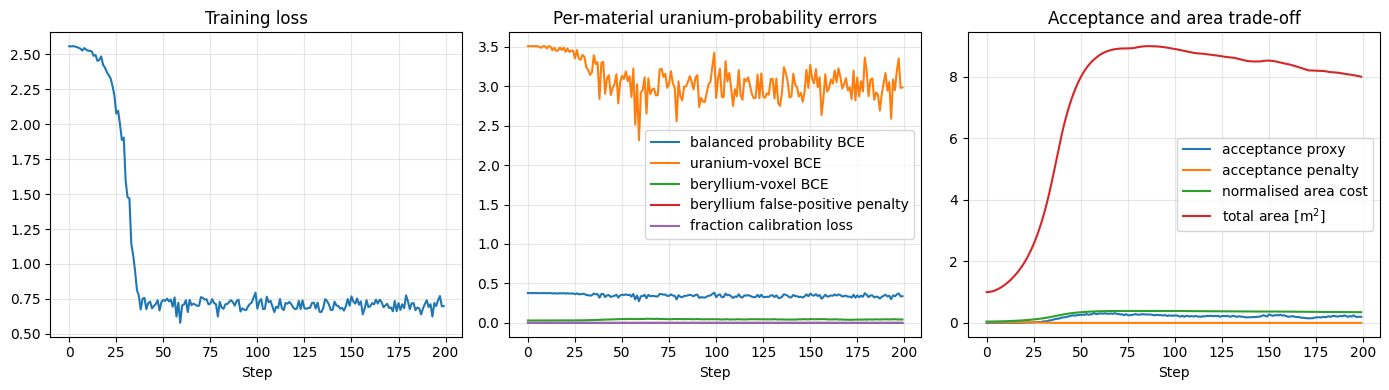

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(history["loss"])
axes[0].set_title("Training loss")
axes[0].set_xlabel("Step")
axes[0].grid(alpha=0.3)

axes[1].plot(history["balanced_probability_bce"], label="balanced probability BCE")
axes[1].plot(history["uranium_bce"], label="uranium-voxel BCE")
axes[1].plot(history["beryllium_bce"], label="beryllium-voxel BCE")
axes[1].plot(history["beryllium_false_positive_penalty"], label="beryllium false-positive penalty")
axes[1].plot(history["uranium_fraction_loss"], label="fraction calibration loss")
axes[1].set_title("Per-material uranium-probability errors")
axes[1].set_xlabel("Step")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history["acceptance"], label="acceptance proxy")
axes[2].plot(history["acceptance_penalty"], label="acceptance penalty")
axes[2].plot(history["area_cost"], label="normalised area cost")
axes[2].plot(history["total_panel_area"], label=r"total area [m$^2$]")
axes[2].set_title("Acceptance and area trade-off")
axes[2].set_xlabel("Step")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Learned detector

After optimisation we inspect both the geometry and the efficiency maps. In a realistic design study we would also enforce hard engineering constraints, but even this toy example already shows the qualitative behaviour:

- voxels that matter most for the accepted muon phase space stay efficient,
- other voxels can become cheaper,
- panel locations shift to improve the trade-off between scattering reconstruction and cost.


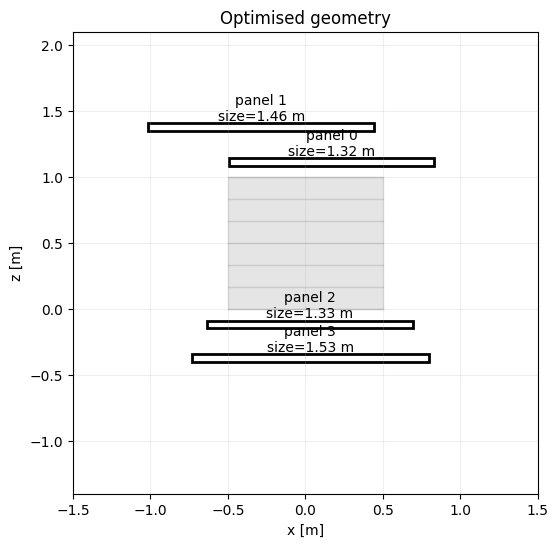

Final global X0 estimate: 0.002 m
Final balanced uranium-probability BCE: 0.2659
Final uranium-voxel BCE: 1.3997
Final beryllium-voxel BCE: 0.1399
Final beryllium false-positive penalty: 0.0024
Final uranium-fraction calibration loss: 0.0096
Final acceptance proxy: 0.2006
Final total panel area: 7.982 m^2
Final normalised area cost: 0.3465
Final mean panel efficiency: 0.8462


In [9]:
with torch.no_grad():
    final_prediction = model(sample_muons(4096))

plot_geometry(model, "Optimised geometry")

uranium_bce, beryllium_bce = per_material_probability_bce(final_prediction)
print(f"Final global X0 estimate: {final_prediction['x0_hat'].item():.3f} m")
print(f"Final balanced uranium-probability BCE: {material_balanced_probability_bce(final_prediction).item():.4f}")
print(f"Final uranium-voxel BCE: {uranium_bce.item():.4f}")
print(f"Final beryllium-voxel BCE: {beryllium_bce.item():.4f}")
print(f"Final beryllium false-positive penalty: {beryllium_false_positive_penalty(final_prediction).item():.4f}")
print(f"Final uranium-fraction calibration loss: {uranium_fraction_calibration_loss(final_prediction).item():.4f}")
print(f"Final acceptance proxy: {final_prediction['acceptance'].item():.4f}")
print(f"Final total panel area: {final_prediction['total_panel_area'].item():.3f} m^2")
print(f"Final normalised area cost: {final_prediction['cost'].item():.4f}")
print(f"Final mean panel efficiency: {final_prediction['mean_efficiency'].item():.4f}")


/var/folders/_z/jj9k3dln24d4m13tc_cfv5dh0000gn/T/ipykernel_19092/3507177693.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


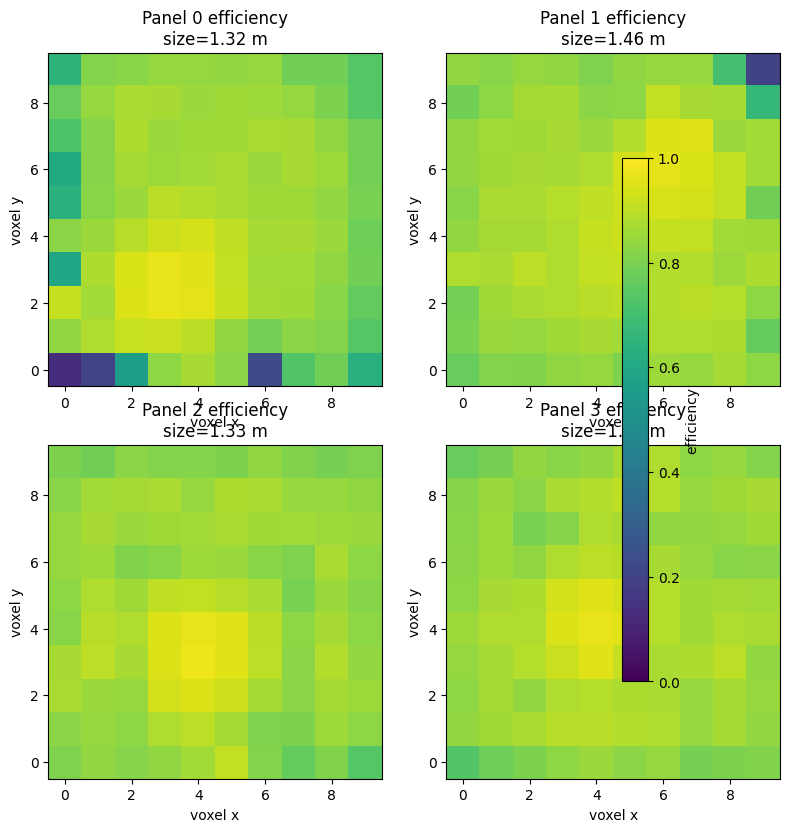

In [10]:
efficiency_maps = torch.sigmoid(model.efficiency_logits).detach().numpy()
panel_sizes = model.panel_sizes().detach().numpy()

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    image = ax.imshow(efficiency_maps[i], vmin=0.0, vmax=1.0, cmap="viridis", origin="lower")
    ax.set_title(f"Panel {i} efficiency\nsize={panel_sizes[i]:.2f} m")
    ax.set_xlabel("voxel x")
    ax.set_ylabel("voxel y")

fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.85, label="efficiency")
plt.tight_layout()
plt.show()


## True vs reconstructed uranium-probability voxel maps

For each passive-volume `z` slice, we compare exactly two 2D `x-y` maps:

- the **true** per-voxel uranium target map, with `1` for uranium and `0` for beryllium,
- the **reconstructed** per-voxel uranium-probability map obtained from the POCA-based reconstruction.

The passive block is mostly beryllium, so the central uranium inclusion should appear as probabilities close to `1` inside the 3x3 core across the middle two `z` layers and close to `0` elsewhere.


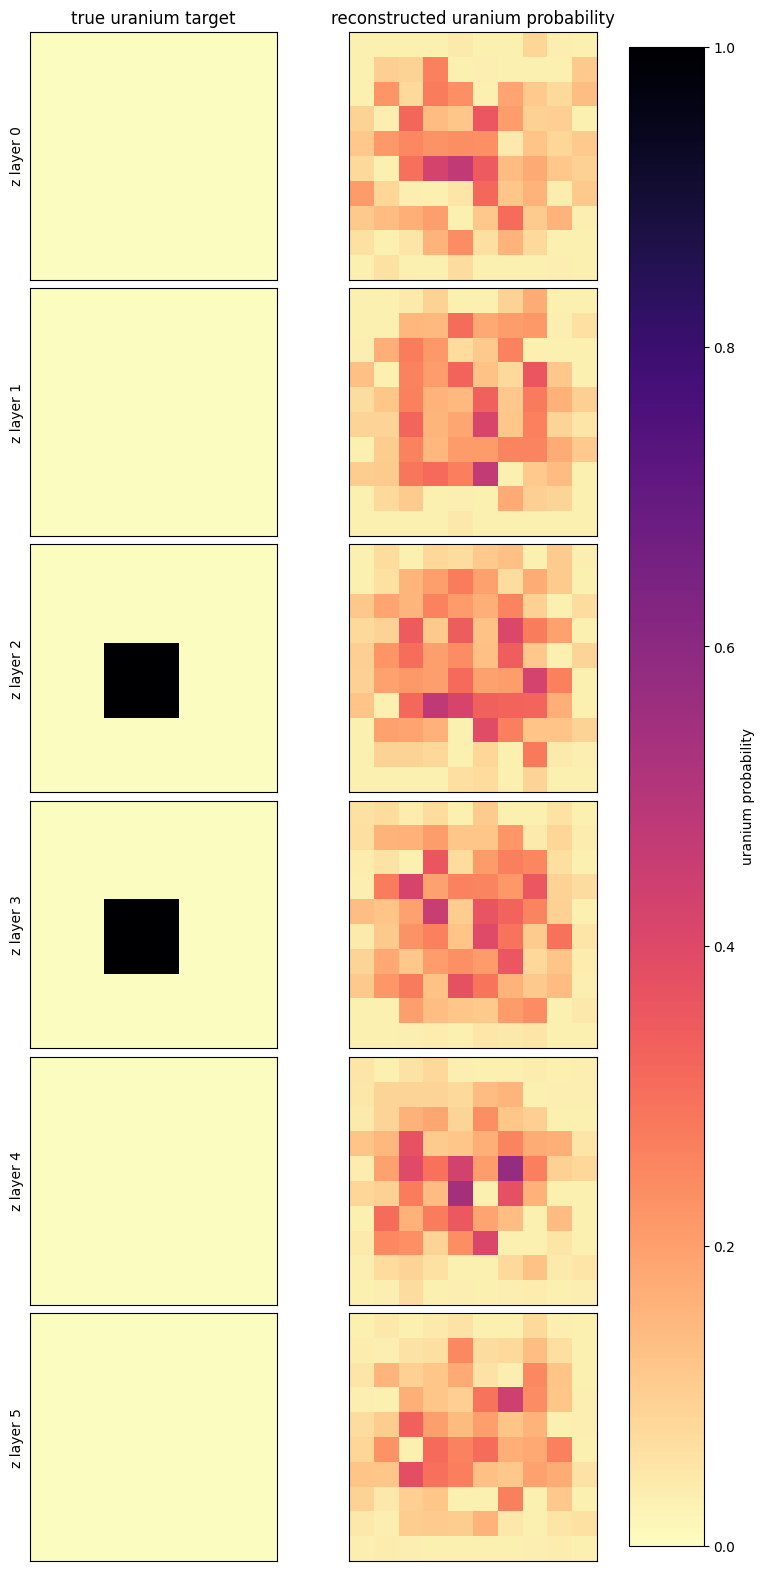

In [11]:
true_map = true_uranium_map.detach().cpu().numpy()
reconstructed_map = final_prediction["reconstructed_uranium_probability"].detach().cpu().numpy()

vmin = 0.0
vmax = 1.0

fig, axes = plt.subplots(N_PASSIVE_LAYERS, 2, figsize=(8, 2.6 * N_PASSIVE_LAYERS), constrained_layout=True)
column_titles = ["true uranium target", "reconstructed uranium probability"]

for col, title in enumerate(column_titles):
    axes[0, col].set_title(title)

for layer in range(N_PASSIVE_LAYERS):
    images = [
        axes[layer, 0].imshow(true_map[layer], origin="lower", cmap="magma_r", vmin=vmin, vmax=vmax),
        axes[layer, 1].imshow(reconstructed_map[layer], origin="lower", cmap="magma_r", vmin=vmin, vmax=vmax),
    ]

    axes[layer, 0].set_ylabel(f"z layer {layer}")
    for col in range(2):
        axes[layer, col].set_xticks([])
        axes[layer, col].set_yticks([])

cbar = fig.colorbar(images[-1], ax=axes.ravel().tolist(), shrink=0.98)
cbar.set_label("uranium probability")
plt.show()


## What made this differentiable?

The optimisation works because we replaced discrete detector logic with smooth surrogates:

- panel edges use sigmoids rather than hard cuts,
- voxel efficiencies are sampled with bilinear interpolation,
- event selection is replaced by continuous event weights,
- hit uncertainty is a differentiable function of efficiency,
- the reconstructed scattering strength is converted smoothly into a uranium probability,
- the final objective is built from ordinary tensor operations.

That is the main differentiable-programming lesson: once the whole reconstruction chain is written as a computation graph, the detector itself can become an optimisable object.


## Exercises

A few natural extensions are:

1. predict multiple material classes instead of just uranium versus beryllium,
2. optimise panel sizes as well as panel positions,
3. replace the single-scatter model with small kicks in each of the 6 passive layers,
4. add an explicit minimum-acceptance penalty with a tunable target acceptance,
5. compare Adam with simple gradient descent.
